# 🟢 **Environment Setup**

In [1]:
%uv pip install -q torchmetrics prettytable pyarrow

Note: you may need to restart the kernel to use updated packages.


# 🟢 **Import**

In [2]:
import os
import json
import time
import yaml
import sys
import math
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pickle
import numpy as np

from tqdm import tqdm
from itertools import cycle
from datetime import datetime
from dataclasses import dataclass, asdict
from prettytable import PrettyTable
from tokenizers import Tokenizer
from torch.utils.data import Dataset, DataLoader
from torch import nn
from torch.nn import functional as F
from torchmetrics.aggregation import MeanMetric

# 🟢 **Utils**

In [3]:
def prepare_data(tokens, seq_len):
    if not isinstance(tokens, torch.Tensor):
        tokens = torch.tensor(tokens, dtype=torch.long)

    n_tokens = tokens.shape[0]

    if n_tokens < seq_len:
        print(f"⚠️ Number of tokens ({n_tokens}) it is less than seq_len={seq_len}.")
        return tokens.unsqueeze(0)

    n_tokens = (n_tokens // seq_len) * seq_len
    tokens = tokens[:n_tokens]
    return tokens.view(-1, seq_len)

In [4]:
def num_trainable_params(model):
  nums = sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6
  return nums

In [5]:
# Benchmarking function
def calculate_time(model, x, num_runs=10):
    torch.cuda.synchronize()
    start = time.time()
    for _ in range(num_runs):
        model(x)
    torch.cuda.synchronize()
    return (time.time() - start) / num_runs

# 🟢 **Dataset**

In [6]:
class Alphabet_NLP_Dataset(Dataset):
    def __init__(self, data, seq_len):
        self.seq_len = seq_len
        data = np.array(data, dtype=np.int64)
        self.data = prepare_data(data, seq_len+1)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        sample = torch.tensor(self.data[idx], dtype=torch.long)
        return sample

# 🟢 **Model**

## 🔴 Multi-Head Attention

In [7]:
class MultiHeadAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.n_embd = config.n_embd
        self.n_head = config.n_head
        self.head_size = self.n_embd // self.n_head

        self.qkv_proj = nn.Linear(self.n_embd, 3*self.n_embd, bias=False)
        self.c_proj = nn.Linear(self.n_embd, self.n_embd, bias=False)
        self.c_proj.residual = True

    def forward(self, x):
        B, T, C = x.shape
        # QKV linear
        q, k, v = self.qkv_proj(x).view(B, T, 3*self.n_head, self.head_size).transpose(1, 2).chunk(3, dim=-3)
        # Scaled Dot Product Attention using pytorch
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        # Reshape and final projection
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.c_proj(y)
        return y

## 🔴 Feed Forward (MLP)

In [8]:
class FeedForward(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.n_embd = config.n_embd
        self.f_expnd = config.f_expnd

        self.up_proj = nn.Linear(self.n_embd, int(self.f_expnd*self.n_embd), bias=False)
        self.down_proj = nn.Linear(int(self.f_expnd*self.n_embd), self.n_embd, bias=False)
        self.down_proj.residual = True
        self.mlp_dropout = nn.Dropout(config.dropout_rate)

    def forward(self, x):
        return self.mlp_dropout(self.down_proj(F.gelu(self.up_proj(x))))

## 🔴 Decoder Block

In [9]:
class DecoderBlock(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.n_embd = config.n_embd
        # Multi Head Attention
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.mha = MultiHeadAttention(config)
        # Feed Forward Neural Network
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.mlp = FeedForward(config)
        self.dropout = nn.Dropout(config.dropout_rate)

    def forward(self, x):
        x = x + self.dropout(self.mha(self.ln1(x)))
        x = x + self.dropout(self.mlp(self.ln2(x)))
        return x

## 🔴 ARK

In [10]:
class ARK(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.wte = nn.Embedding(config.vocab_size, config.n_embd) # Token embedding
        self.wpe = nn.Embedding(config.max_seq_len, config.n_embd) # Position embedding
        self.decoders = nn.ModuleList([DecoderBlock(config) for _ in range(config.n_layer)]) # Decoders
        self.lnf = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False) # Classifier
        self.lm_head.weight = self.wte.weight # Weight tying

        self.apply(self._init_weights)

    def _init_weights(self, module):
        std = 0.02
        if isinstance(module, nn.Linear):
            if hasattr(module, 'residual'):
                std *= (2*self.config.n_layer)**-0.5
            nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=std)

    def forward(self, idx):
        B, T = idx.shape
        # Token Embedding + Position Embedding
        x = self.wte(idx) + self.wpe(torch.arange(T, device=idx.device))
        # Decoders
        for decoder in self.decoders:
            x = decoder(x)
        # Classifier
        x = self.lnf(x)
        logits = self.lm_head(x)
        return logits

# 🟢 **Config**

In [ ]:
@dataclass
class DatasetConfig:
    train_path: str
    valid_path: str
    tokenizer_path: str
    batch_size: int = 32
    seq_len: int = 128


@dataclass
class ARKConfig:
    vocab_size: int = 50257
    max_seq_len: int = 1024
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 64
    f_expnd: int = 4
    dropout_rate: float = 0.2


@dataclass
class OptimizerConfig:
    max_lr: float = 3e-4
    betas: tuple = (0.9, 0.95)
    weight_decay: float = 0.1
    fused: bool = True
    warmup_steps: int = 256
    alpha: float = 0.1


@dataclass
class TrainConfig:
    seed: int = 42
    device: str = 'cuda'
    total_tokens: int = 0
    log_interval_tokens: int = 50_000
    log_dir: str = 'logs'
    run_name: str = 'ark-alpha-mini-v1'


@dataclass
class GenerationConfig:
    prompts: list[str]
    T: float = 0.9
    max_seq_len: int = 128
    top_k: int = 10
    n_rep: int = 3
    seed: int = 42


@dataclass
class MasterConfig:
    data: DatasetConfig
    model: ARKConfig
    optimizer: OptimizerConfig
    train: TrainConfig
    generation: GenerationConfig

# 🟢 **Functions ⚙️**

## 🔴 Logger

In [ ]:
log_dir = '/data/logs'

# Logger class for saving and plotting training logs
class Logger:
    """
    Manages training history logging, saving to disk, and plotting learning curves.
    """
    def __init__(self, log_dir='/data/logs', run_name='default_run', config=None):
        self.base_log_dir = log_dir
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.run_log_dir = os.path.join(self.base_log_dir, f"{run_name}_{timestamp}") # Run-specific, timestamped directory
        os.makedirs(self.run_log_dir, exist_ok=True)
        # Ensure the base log directory exists for model.pt and config.yaml
        os.makedirs(self.base_log_dir, exist_ok=True)

        # For backward compatibility with existing usages of self.log_dir
        self.log_dir = self.run_log_dir

        self.history = {
            'train_loss': [],
            'valid_loss': [],
            'best_valid_loss': float('inf'),
            'seen_tokens': [],
            'elapsed_time': []
        }
        self.config = config # Store the full MasterConfig

    def log(self, train_loss, valid_loss, seen_tokens, elapsed_time=0):
        self.history['train_loss'].append(train_loss)
        self.history['valid_loss'].append(valid_loss)
        self.history['seen_tokens'].append(seen_tokens)
        self.history['elapsed_time'].append(elapsed_time)

    def save(self, model, optimizer):
        current_loss_valid = self.history['valid_loss'][-1]
    
        # Check if current validation loss is the best so far
        if current_loss_valid < self.history['best_valid_loss']:
    
            # Update best validation loss FIRST
            self.history['best_valid_loss'] = current_loss_valid
    
            # Save model
            model_path = os.path.join(
                self.run_log_dir,
                'ark-alpha-mini-v1-2.9M.pt'
            )
    
            torch.save(
                dict(
                    model_state_dict=model.state_dict(),
                    optimizer_state_dict=optimizer.state_dict()
                ),
                model_path
            )
    
            print(f"\n✅ Model Saved to {model_path}!")
    
            # Save config corresponding to this model
            if self.config:
                best_config_path = os.path.join(
                    self.run_log_dir,
                    'config.yaml'
                )
    
                with open(best_config_path, 'w') as f:
                    yaml.dump(
                        asdict(self.config),
                        f,
                        sort_keys=False,
                        indent=4
                    )
    
                print(f"✅ Model's Config Saved to {best_config_path}!")
    
        # Save history AFTER best_valid_loss has been updated
        file_path_history = os.path.join(
            self.run_log_dir,
            'loss_history.json'
        )
    
        with open(file_path_history, 'w') as f:
            json.dump(
                self.history,
                f,
                indent=4
            )
    
        # Plot learning curve
        self.plot()

    def plot(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.history['seen_tokens'], self.history['train_loss'], label='Train Loss')
        plt.plot(self.history['seen_tokens'], self.history['valid_loss'], label='Valid Loss')
        plt.xlabel('Seen Tokens')
        plt.ylabel('Loss')
        plt.title(f'Learning Curve - Run: {os.path.basename(self.run_log_dir)}') # Add run name to plot title
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(self.run_log_dir, 'learning_curve.png')) # Save to run-specific folder
        plt.show()

## 🔴 Train ➰

In [13]:
class LLMTrainer:
    """
    Trainer handles training loops, periodic evaluation, logging, and sample generation.
    """
    def __init__(self, model, optimizer, train_loader, valid_loader, tokenizer,
                 config, loss_fn=F.cross_entropy):

        self.model = model
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.tokenizer = tokenizer
        self.loss_fn = loss_fn
        self.config = config
        self.device = config.train.device

        self.seen_tokens = 0
        self.token_eval_counter = 0
        self.total_tokens = config.train.total_tokens
        self.log_interval_tokens = config.train.log_interval_tokens

        self.logger = Logger(log_dir=config.train.log_dir, run_name=config.train.run_name, config=config)
        self._print_config_summary()

        self.generation = config.generation


    def train(self):
        """
        Main training loop.
        Runs exactly one complete epoch over the training dataset.
        """
    
        # ---------------------------------------------------------
        # Initial evaluation before any training
        # ---------------------------------------------------------
        initial_loss = self.evaluate()
    
        self.logger.log(
            initial_loss,
            initial_loss,
            0
        )
    
        print(
            f"👶 [Initial] Train Loss (Untrained Model): "
            f"{initial_loss:.4f}\n"
        )
    
        # ---------------------------------------------------------
        # Training setup
        # ---------------------------------------------------------
        loss_train = MeanMetric()
    
        self.model.train()
    
        step = 0
        batches = 0
    
        start_time = time.time()
        total_time_elapsed = 0
    
        # Number of optimizer steps in exactly one epoch
        total_steps = len(self.train_loader)
    
        print(f"🎯 Total training batches (1 epoch): {total_steps:,}")
        print(f"🎯 Total training tokens: {self.total_tokens:,}\n")
    
        # ---------------------------------------------------------
        # One complete epoch
        # ---------------------------------------------------------
        with tqdm(
            total=self.total_tokens,
            desc="Training",
            unit="t"
        ) as pbar:
    
            for inputs in self.train_loader:
    
                inputs = inputs.to(self.device)
    
                # -------------------------------------------------
                # Forward pass
                # -------------------------------------------------
                logits = self.model(inputs[:, :-1])
    
                # -------------------------------------------------
                # Calculate loss
                # -------------------------------------------------
                loss = self.loss_fn(
                    logits.view(-1, logits.shape[-1]),
                    inputs[:, 1:].flatten()
                )
    
                # -------------------------------------------------
                # Backward pass
                # -------------------------------------------------
                loss.backward()
    
                # -------------------------------------------------
                # Gradient clipping
                # -------------------------------------------------
                nn.utils.clip_grad.clip_grad_norm_(
                    self.model.parameters(),
                    max_norm=1.
                )
    
                # -------------------------------------------------
                # Learning rate
                # -------------------------------------------------
                lr = get_lr(
                    step,
                    total_steps,
                    self.config.optimizer
                )
    
                for group in self.optimizer.param_groups:
                    group['lr'] = lr
    
                # -------------------------------------------------
                # Update model
                # -------------------------------------------------
                self.optimizer.step()
                self.optimizer.zero_grad()
    
                # -------------------------------------------------
                # Running loss
                # -------------------------------------------------
                loss_train.update(
                    loss.item(),
                    inputs.shape[0]
                )
    
                # -------------------------------------------------
                # Token counting
                # -------------------------------------------------
                num_tokens_this_batch = inputs[:, :-1].numel()
    
                self.seen_tokens += num_tokens_this_batch
                self.token_eval_counter += num_tokens_this_batch
    
                step += 1
                batches += 1
    
                elapsed = time.time() - start_time
    
                batches_per_sec = (
                    batches / elapsed
                    if elapsed > 0
                    else 0
                )
    
                # -------------------------------------------------
                # Progress bar
                # -------------------------------------------------
                pbar.set_postfix({
                    "B/S": f"{batches_per_sec:.2f}",
                    "Loss": f"{loss_train.compute().item():.4f}",
                    "LR": f"{self.optimizer.param_groups[0]['lr']:.2e}",
                })
    
                pbar.update(num_tokens_this_batch)
    
                # -------------------------------------------------
                # Periodic evaluation
                # -------------------------------------------------
                if (
                    self.token_eval_counter >= self.log_interval_tokens
                    or
                    step == total_steps
                ):
    
                    total_time_elapsed += elapsed
    
                    # Temporarily disable tqdm
                    pbar.disable = True
    
                    # ---------------------------------------------
                    # Validation
                    # ---------------------------------------------
                    loss_valid = self.evaluate()
    
                    print(
                        f"\nValid Loss: {loss_valid:.4f}"
                    )
    
                    # ---------------------------------------------
                    # Log
                    # ---------------------------------------------
                    self.logger.log(
                        loss_train.compute().item(),
                        loss_valid,
                        self.seen_tokens,
                        total_time_elapsed
                    )
    
                    # ---------------------------------------------
                    # Save
                    # ---------------------------------------------
                    self.logger.save(
                        self.model,
                        self.optimizer
                    )
    
                    # ---------------------------------------------
                    # Generate
                    # ---------------------------------------------
                    if self.generation:
                        self.generate()
    
                    sys.stdout.flush()
    
                    # Redraw tqdm
                    pbar.clear()
                    pbar.disable = False
                    pbar.refresh()
    
                    # Reset evaluation counter
                    self.token_eval_counter = 0
    
                    batches = 0
                    start_time = time.time()
    
            # -----------------------------------------------------
            # Final learning curve
            # -----------------------------------------------------
            self.logger.plot()

    def evaluate(self):
        """
        Evaluate model on validation set.
        """
        loss_valid = MeanMetric()
        self.model.eval()
        with torch.no_grad():
            for inputs in self.valid_loader:
                inputs = inputs.to(self.device)
                logits = self.model(inputs[:, :-1])
                loss = self.loss_fn(logits.view(-1, logits.shape[-1]), inputs[:, 1:].flatten())
                loss_valid.update(loss.item(), inputs.shape[0])
        return loss_valid.compute().item()

    def generate(self):
        """
        Generate and print text samples from the model.
        """
        generated_texts = []
        for prompt in self.generation.prompts:
            gen_text = generate(
                self.model, self.tokenizer, prompt,
                n_rep=self.generation.n_rep,
                max_seq_len=self.generation.max_seq_len,
                T=self.generation.T, top_k=self.generation.top_k,
                seed=self.generation.seed)
            generated_texts.append(gen_text)

        # Use display_chat_style for better visualization during training
        for i, prompt in enumerate(self.generation.prompts):
            print(f"\n{'='*100}") # Separator for clarity
            display_chat_style(prompt, generated_texts[i], self.tokenizer)
            print(f"{'='*100}") # Separator for clarity

    def _print_config_summary(self):
        """
        Print a summary table of training configuration.
        """
        table = PrettyTable()
        table.title = "Training Configuration Summary"
        table.field_names = ["Component", "Details"]
        # Model
        table.add_row(["Model Type", str(self.model.config).replace("Config", "")])
        # Optimizer
        optimizer_name = self.optimizer.__class__.__name__
        optimizer_groups_info = [
            f"Group {i+1} ({'Weight_Decay' if group.get('weight_decay', 0) > 0 else 'No-Weight_Decay'}): "
            f"LR={group.get('lr', 'default')}, betas={group.get('betas')}, "
            f"WD={group.get('weight_decay', 0)}, fused={group.get('fused')}"
            for i, group in enumerate(self.optimizer.param_groups)
        ]
        optimizer_display = f"{optimizer_name}\n" + "\n".join(optimizer_groups_info)
        table.add_row(["Optimizer", optimizer_display])
        # Parameters
        total_params = sum(p.numel() for p in self.model.parameters())
        te_params = self.model.wte.weight.numel()
        table.add_row(["Total Parameters (Tr+TE)", f"{total_params:,} ({total_params-te_params:,}+{te_params:,})"])

        table.add_row(["Loss Function", self.loss_fn.__name__ if hasattr(self.loss_fn, '__name__') else str(self.loss_fn)])
        table.add_row(["Batch Shape", f"{self.train_loader.batch_size}x{self.train_loader.dataset[0].shape[-1]-1}"])
        table.add_row(["Device", self.device])
        table.add_row(["Max Tokens", f"{self.total_tokens:,}"])
        table.add_row(["Log Interval Tokens", f"{self.log_interval_tokens:,}"])
        print(table)

## 🔴 Optimizer

In [14]:
def configure_optimizer(model, config: OptimizerConfig):
    # start with all of the candidate parameters (that require grad)
    param_dict = {n: p for n, p in model.named_parameters() if p.requires_grad}

    # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
    # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
    decay_params = [p for _, p in param_dict.items() if p.ndim >= 2]
    nodecay_params = [p for _, p in param_dict.items() if p.ndim < 2]

    optim_groups = [
        {"params": decay_params, "weight_decay": config.weight_decay},
        {"params": nodecay_params, "weight_decay": 0.0}
    ]

    num_decay_params = sum(p.numel() for p in decay_params)
    num_nodecay_params = sum(p.numel() for p in nodecay_params)
    print(f"🔹 num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
    print(f"🔹 num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")

    # Define Optimizer
    optimizer = torch.optim.AdamW(
        optim_groups,
        lr=config.max_lr,
        betas=config.betas,
        fused=config.fused)

    return optimizer

In [15]:
def get_lr(step, total_steps, config: OptimizerConfig):
    assert step <= total_steps

    # 1. Linear warmup for warmup_steps
    if step < config.warmup_steps:
        return config.max_lr * (step+1) / config.warmup_steps

    # 2. Linear decay down to min learning rate
    decay_ratio = (step - config.warmup_steps) / (total_steps - config.warmup_steps) # [0, 1]
    assert 0 <= decay_ratio <= 1
    return config.max_lr * (config.alpha + (1 - decay_ratio)) / (config.alpha + 1)

In [16]:
def get_lr(step, total_steps, config: OptimizerConfig):
    assert step <= total_steps

    # Linear decay down to min learning rate
    decay_ratio = step / total_steps  # [0, 1]
    assert 0 <= decay_ratio <= 1
    return config.max_lr * (config.alpha + (1 - decay_ratio)) / (config.alpha + 1)

In [17]:
def get_lr(step, total_steps, config: OptimizerConfig):
    # Ensure step doesn't exceed total_steps for LR calculation purposes
    # This addresses the AssertionError when step might slightly exceed total_steps
    # due to how the training loop finishes.
    step = min(step, total_steps)

    # 1. Linear warmup for warmup_steps
    if step < config.warmup_steps:
        return config.max_lr * (step + 1) / config.warmup_steps

    # 2. if it > lr_decay_iters, return min learning rate
    min_lr = config.max_lr * config.alpha / (config.alpha + 1)
    decay_steps = total_steps - config.warmup_steps

    # Handle the case where decay_steps is zero (no decay phase or warmup covers all steps)
    if decay_steps <= 0:
        return min_lr

    # 3. in between, use cosine decay down to min learning rate
    decay_ratio = (step - config.warmup_steps) / decay_steps
    # Ensure decay_ratio is clamped between 0 and 1
    decay_ratio = max(0.0, min(1.0, decay_ratio))

    cosine_factor = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + (config.max_lr - min_lr) * cosine_factor

## 🔴 Generate

In [18]:
def generate(model, tokenizer, prompt, n_rep=5, max_seq_len=128, T=0.9, top_k=10, device='cuda', seed=42):
    # Get the token ID for <|endoftext|>
    eot_token_id = tokenizer.encode("<|endoftext|>").ids[0]

    # Tokenize the prompt and convert it to a tensor on the specified device (e.g., GPU)
    prompt_token_ids = tokenizer.encode(prompt).ids
    initial_prompt_len = len(prompt_token_ids)
    inputs = torch.tensor(prompt_token_ids, dtype=torch.int, device=device)

    # Repeat the input prompt n_rep times to generate multiple sequences in parallel
    inputs = inputs.unsqueeze(0).repeat(n_rep, 1)  # Shape: [B, T_prompt]

    # Set the model to evaluation mode
    model.eval()

    # Initialize a random number generator for sampling
    sample_rng = torch.Generator(device=device)
    sample_rng.manual_seed(seed)

    # Track which sequences are still active
    is_finished = torch.zeros(n_rep, dtype=torch.bool, device=device)

    # Disable gradient calculation for faster inference
    with torch.no_grad():
        # Continue generating tokens until reaching the maximum sequence length
        # The loop should continue until the total length reaches max_seq_len OR all sequences are finished
        while inputs.shape[-1] < max_seq_len:
            # Forward pass: get logits from the model. Pass only the current sequence as input.
            # The model takes the entire 'inputs' and predicts the next token based on the context.
            # We need to take the last token's logits for prediction.
            logits = model(inputs)  # Shape: [B, T_current, vocab_size]

            # Apply temperature scaling and softmax to get probabilities for the next token
            probs = torch.softmax(logits[:, -1, :] / T, dim=-1)  # Shape: [B, vocab_size]

            # Select the top_k tokens with the highest probabilities
            topk_probs, topk_indices = torch.topk(probs, k=top_k, dim=-1)  # Shape: [B, top_k]

            # Sample one token from the top_k candidates based on their probabilities
            sampled = torch.multinomial(topk_probs, 1, generator=sample_rng)  # Shape: [B, 1]

            # Map the sampled indices back to the original token IDs
            next_token = torch.gather(topk_indices, -1, sampled).squeeze(-1) # Shape: [B]

            # For finished sequences, force pad with eot_token_id again to avoid changing inputs
            # Only update next_token for sequences that are not yet finished
            next_token = torch.where(is_finished, torch.tensor(eot_token_id, device=device), next_token)

            # Update finished mask
            is_finished = is_finished | (next_token == eot_token_id)

            # Append the sampled tokens to the input sequence
            inputs = torch.cat((inputs, next_token.unsqueeze(-1)), dim=-1)  # Shape: [B, T_current + 1]

            # If all sequences are finished, we can break early
            if torch.all(is_finished):
                break

    # Decode only the generated part, not the initial prompt.
    generated_continuations = []
    for i in range(inputs.shape[0]):
        # Extract only the generated tokens (after the initial prompt)
        continuation_ids = inputs[i, initial_prompt_len:].tolist()
        # Find the first EOT token and truncate there
        try:
            first_eot_idx = continuation_ids.index(eot_token_id)
            continuation_ids = continuation_ids[:first_eot_idx]
        except ValueError:
            pass # No EOT token found, use all generated tokens

        generated_continuations.append(tokenizer.decode(continuation_ids))

    return generated_continuations

In [19]:
def display_chat_style(prompt, generated_continuations_list, tokenizer, delay=0.03):
    """
    Display generated text in a token-by-token ChatARK-like style,
    showing only the continuation.
    - generated continuation in cyan
    """
    for i, generated_continuation_text in enumerate(generated_continuations_list):
        print(f"\n[Sample {i+1}]")

        # Tokenize the generated continuation to display token-by-token
        continuation_token_ids = tokenizer.encode(generated_continuation_text).ids
        cont_tokens_text = [tokenizer.decode([tid]) for tid in continuation_token_ids]

        # Print continuation token-by-token without color
        for token in cont_tokens_text:
            sys.stdout.write(token)
            sys.stdout.flush()
            time.sleep(delay)
        print()

# 🟢 **Training Process 〽️**

In [46]:
torch.cuda.empty_cache()

In [ ]:
base_path = "/data/parquet/"

files = [
    "Alphabet_NLP_Dataset.parquet",
    "Alphabet_Codex_Dataset.parquet",
    "Alphabet_Jurisprudence_Dataset.parquet",
    "Alphabet_Quran_Dataset.parquet",
    "Alphabet_Science_Dataset.parquet",
    "Alphabet_Technology_Dataset.parquet",
    "Alphabet_Philologia_Dataset.parquet"
]

dfs = [pd.read_parquet(base_path + f) for f in files]
df = pd.concat(dfs, ignore_index=True)

full_data = df.values.tolist()

n_total = len(full_data)
n_valid = int(0.2 * n_total)
n_train = n_total - n_valid

train_data = full_data[:n_train]
valid_data = full_data[n_train:]

os.makedirs("/data/dataset", exist_ok=True)

with open('/data/dataset/Alphabet_NLP_Dataset_train.pkl', 'wb') as f:
    pickle.dump(train_data, f)

with open('/data/dataset/Alphabet_NLP_Dataset_valid.pkl', 'wb') as f:
    pickle.dump(valid_data, f)

print(f"Train size: {len(train_data)}, Valid size: {len(valid_data)}")


cfg = MasterConfig(

    data=DatasetConfig(
        train_path = "/data/dataset/Alphabet_NLP_Dataset_train.pkl",
        valid_path = "/data/dataset/Alphabet_NLP_Dataset_valid.pkl",
        tokenizer_path = "/data/tokenizer/bpe-tokenizer_alphabet_nlp_dataset_10,000.json",
        batch_size=16, # Increased batch size
        seq_len=64), # Increased sequence length

    model=ARKConfig(
        vocab_size=10_000,
        max_seq_len=1024,
        n_layer=8,
        n_head=16,
        n_embd=128,
        f_expnd=4),

    optimizer=OptimizerConfig(
        max_lr=3e-4, # Adjusted learning rate to a more typical value for training
        betas=(0.9, 0.95),
        weight_decay=0.1,
        fused=True,
        warmup_steps=20, # Adjusted warmup steps for smaller total_tokens
        alpha=0.1),

    train=TrainConfig(
        seed=42,
        device='cuda' if torch.cuda.is_available() else 'cpu', # Dynamically set device
        total_tokens=0,
        log_interval_tokens=25600, # Log every ~1 epoch of the training data
        log_dir = "/data/logs",
        run_name='ark-alpha-mini-v1'),

    generation=GenerationConfig(
        prompts=['سلام'],
        T=0.9,
        max_seq_len=64, # Adjusted to match training seq_len
        top_k=10,
        n_rep=3,
        seed=42)
)

Train size: 809, Valid size: 202


In [21]:
# Set a manual seed for reproducibility across runs
torch.manual_seed(cfg.train.seed)

# Load tokenizer - Moved here to ensure it's defined before use in this cell
tokenizer = Tokenizer.from_file(cfg.data.tokenizer_path)

# Load raw training and validation data from disk (.pkl files)
with open(cfg.data.train_path, 'rb') as f:
    raw_train_data = pickle.load(f)

with open(cfg.data.valid_path, 'rb') as f:
    raw_valid_data = pickle.load(f)

# Process raw data into token IDs
# Assuming each item in raw_data is a list like ['prompt', 'response']
# We need to concatenate prompt (index 0) and response (index 1) and tokenize them.
tokenized_train_sequences = []
for item in raw_train_data:
    # Ensure item has at least 2 elements for prompt and response
    if len(item) > 1:
        prompt_text = str(item[0])
        response_text = str(item[1])
        full_text = prompt_text + " " + response_text
        tokenized_train_sequences.append(tokenizer.encode(full_text).ids)
    else:
        print(f"Skipping malformed train data item: {item}")

tokenized_valid_sequences = []
for item in raw_valid_data:
    # Ensure item has at least 2 elements for prompt and response
    if len(item) > 1:
        prompt_text = str(item[0])
        response_text = str(item[1])
        full_text = prompt_text + " " + response_text
        tokenized_valid_sequences.append(tokenizer.encode(full_text).ids)
    else:
        print(f"Skipping malformed valid data item: {item}")

print("📊 Number of tokenized sequences")
print(f"🔹 Train: {len(tokenized_train_sequences):,} sequences")
print(f"🔹 Valid: {len(tokenized_valid_sequences):,} sequences")
print()

# Flatten the list of tokenized sequences into a single list of tokens
flattened_train_data = [token for sublist in tokenized_train_sequences for token in sublist]
flattened_valid_data = [token for sublist in tokenized_valid_sequences for token in sublist]

print("📊 Number of flattened tokens")
print(f"🔹 Train: {len(flattened_train_data):,} tokens")
print(f"🔹 Valid: {len(flattened_valid_data):,} tokens")
print()

# --- Automatic checking to prevent errors ---
def safe_dataset_creation(data_list, seq_len, name="dataset"):
    # Pass the already tokenized lists to Alphabet_NLP_Dataset
    dataset = Alphabet_NLP_Dataset(data_list, seq_len)
    if len(dataset) == 0:
        print(f"⚠️ {name} dataset is empty after processing (no samples with seq_len={seq_len})")
        return None
    return dataset

train_set = safe_dataset_creation(flattened_train_data, cfg.data.seq_len, "Train")
valid_set = safe_dataset_creation(flattened_valid_data, cfg.data.seq_len, "Valid")

if train_set is not None and len(train_set) > 0:

    train_tokens = len(train_set) * cfg.data.seq_len
    cfg.train.total_tokens = train_tokens

    print(f"🎯 Actual training tokens: {cfg.train.total_tokens:,}")

else:
    cfg.train.total_tokens = 0
    print("⚠️ Train dataset is empty.")

# --- Extra check before creating DataLoader ---
if train_set is not None and len(train_set) > 0:
    train_loader = DataLoader(train_set, batch_size=cfg.data.batch_size,
                              shuffle=True, pin_memory=True, num_workers=2)
    print(f"📊 Train: {len(train_loader):,} batches")
else:
    print("⚠️ Train dataset is empty, skipping DataLoader creation.")
    train_loader = None

if valid_set is not None and len(valid_set) > 0:
    valid_loader = DataLoader(valid_set, batch_size=cfg.data.batch_size,
                              shuffle=False, pin_memory=True, num_workers=2)
    print(f"📊 Valid: {len(valid_loader):,} batches")
else:
    print("⚠️ Valid dataset is empty, skipping DataLoader creation.")

📊 Number of tokenized sequences
🔹 Train: 809 sequences
🔹 Valid: 202 sequences

📊 Number of flattened tokens
🔹 Train: 352,416 tokens
🔹 Valid: 58,336 tokens

🎯 Actual training tokens: 346,944
📊 Train: 339 batches
📊 Valid: 57 batches


In [22]:
def num_trainable_params(model):
  nums = sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6
  return nums

model = ARK(cfg.model).to(cfg.train.device)

print(model)
print(f"\n📊 Number of Parameters: {num_trainable_params(model):.2f}M")

ARK(
  (wte): Embedding(10000, 128)
  (wpe): Embedding(1024, 128)
  (decoders): ModuleList(
    (0-7): 8 x DecoderBlock(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mha): MultiHeadAttention(
        (qkv_proj): Linear(in_features=128, out_features=384, bias=False)
        (c_proj): Linear(in_features=128, out_features=128, bias=False)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): FeedForward(
        (up_proj): Linear(in_features=128, out_features=512, bias=False)
        (down_proj): Linear(in_features=512, out_features=128, bias=False)
        (mlp_dropout): Dropout(p=0.2, inplace=False)
      )
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (lnf): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (lm_head): Linear(in_features=128, out_features=10000, bias=False)
)

📊 Number of Parameters: 2.99M


In [23]:
optimizer = configure_optimizer(model, cfg.optimizer)
optimizer

🔹 num decayed parameter tensors: 34, with 2,983,936 parameters
🔹 num non-decayed parameter tensors: 34, with 4,352 parameters


AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.95)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: True
    lr: 0.0003
    maximize: False
    weight_decay: 0.1

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.95)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: True
    lr: 0.0003
    maximize: False
    weight_decay: 0.0
)

+-----------------------------------------------------------------------------------------------------------------------------------+
|                                                   Training Configuration Summary                                                  |
+--------------------------+--------------------------------------------------------------------------------------------------------+
|        Component         |                                                Details                                                 |
+--------------------------+--------------------------------------------------------------------------------------------------------+
|        Model Type        | ARK(vocab_size=10000, max_seq_len=1024, n_layer=8, n_head=16, n_embd=128, f_expnd=4, dropout_rate=0.2) |
|        Optimizer         |                                                 AdamW                                                  |
|                          |                Group 1 (Weight_De

/tmp/ipykernel_182/217509898.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample = torch.tensor(self.data[idx], dtype=torch.long)


👶 [Initial] Train Loss (Untrained Model): 9.2168

🎯 Total training batches (1 epoch): 339
🎯 Total training tokens: 346,944



Training:   7%|█▎                | 24576/346944 [00:01<00:14, 23022.50t/s, B/S=14.16, Loss=8.8050, LR=3.00e-04]


Valid Loss: 8.3569

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


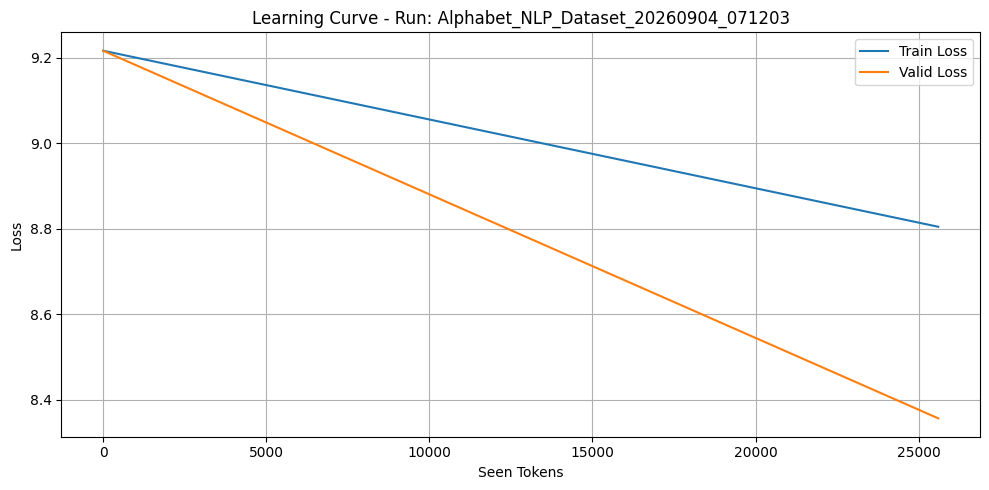



[Sample 1]
 ��َّ����� و می���أ آن
، وََّّ��� داده��� حاصل.������ و،�����.
 آن و می، باَّ میَّ��� حاصل قرار، با������،
 می��� داده��َّ در����� حاصل��� حاصل و. آن

[Sample 2]
 ���َّ و���.��� داده���.��َّ. در با با با با��� در��� دو، میَّ و آن و،�� با آن آن���أ در در��َّ������. می�����
-.
 می.���ی میََّّ و��� با،

[Sample 3]
 .، در���. در�� و و،، در. در
 با���أ.���، با..�����.�� در�� در��� حاصل
��َّ با���ی��. در می.�����،��� با����� در با��


Training:  14%|██▋                | 50176/346944 [00:13<00:41, 7079.21t/s, B/S=42.09, Loss=8.3889, LR=2.94e-04]


Valid Loss: 7.5919

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


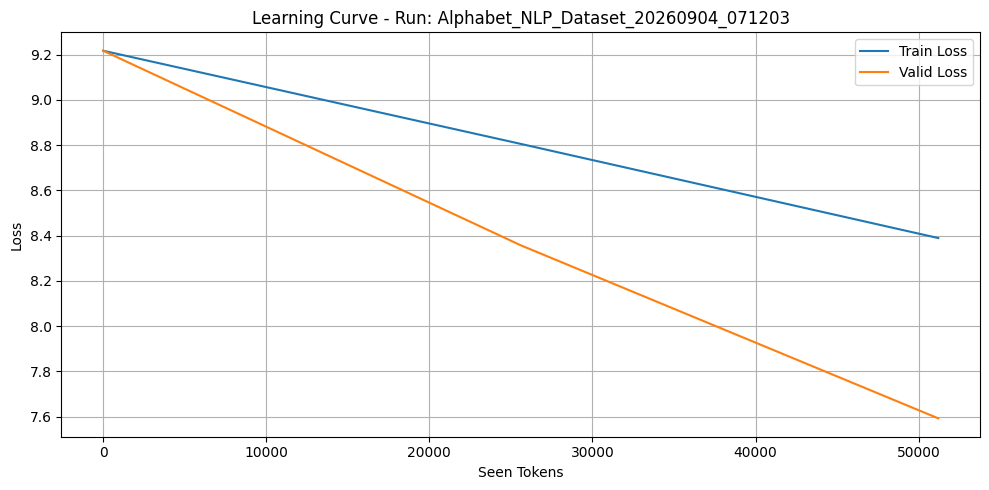



[Sample 1]
 �� که�����. که��� داده در در، و در.
-��� که���ها��� آن،�����های، می با
 و
��� و در��� خود می��� در�� در
 می���.

 با در��ی���ی در،. که

[Sample 2]
 �� می������های��� آن و و�� و با آن. و با آن، آن���َّ و. می��� که،.

- در آن��� استفاده با آن��
�����ها که����� داده با��� در در. آن با در در،��� و،

[Sample 3]
 . و آن���. آن�� در و،، با با می��های به با می با در آن��ها، و�� در��ها��.


 می و با��های��� که با�������� و به�����ها با��


Training:  22%|████▏              | 75776/346944 [00:23<00:48, 5581.68t/s, B/S=43.76, Loss=8.0061, LR=2.81e-04]


Valid Loss: 7.0325

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


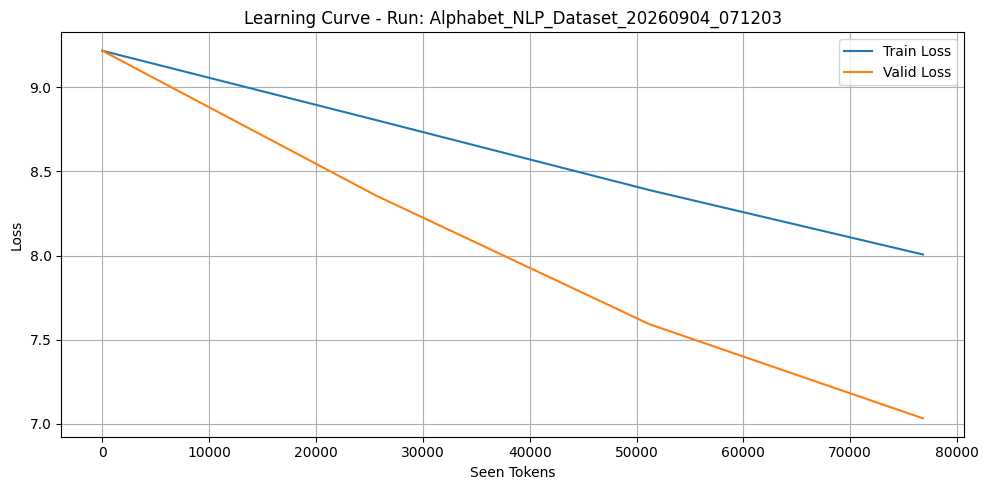



[Sample 1]
 ��شود����� در به��شود در..��� در��� که��� آن، با��� که.
��های و از، که در با می آن می��� را با��� در�����، می���.

 آن با����� در��� را. و آن

[Sample 2]
 ��
.
.
 در و،��های در می��� با در به و�� و و در می می آن و.

 می����� و���.
. از،���. که

�� و در و���. در��� در می��� و��� و.

[Sample 3]
 . و می���. می�����های و، می���های می�����ها می��شود،�����های��ی��شود می�����ی���شود، در��های به از که������� و�����شود���ی���


Training:  29%|█████▎            | 101376/346944 [00:34<00:47, 5118.83t/s, B/S=41.34, Loss=7.6800, LR=2.61e-04]


Valid Loss: 6.6561

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


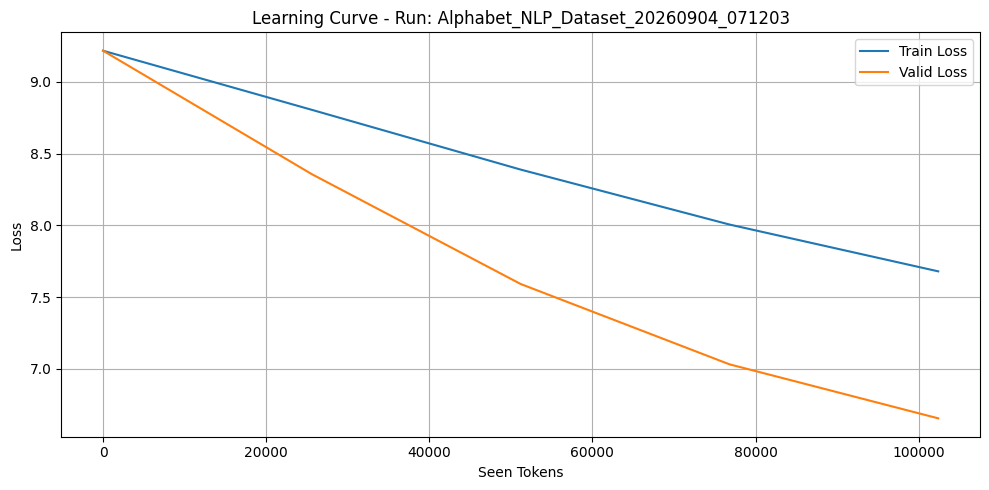



[Sample 1]
 �� به�����. که�� و از، و می.
 در���ها و.
 در.
��های و آن، با��های که می���های آن، می��ها از در��ی��شود.



،، در از

[Sample 2]
 �� که و���.
 که به،��های، می��� که. از���ی��� را و،..������ها به���، آن و��. به��ی،��شود


 در این.��شود در، می در می به��� و در

[Sample 3]
 . و.
. از�����های در و،، آن��های که و. در از���های�����های��ی��شود.، می�� و.��ی���.
���شود.
��� و در از�� و. از��


Training:  37%|██████▋           | 128000/346944 [00:43<00:29, 7410.93t/s, B/S=39.70, Loss=7.4215, LR=2.35e-04]


Valid Loss: 6.4128

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


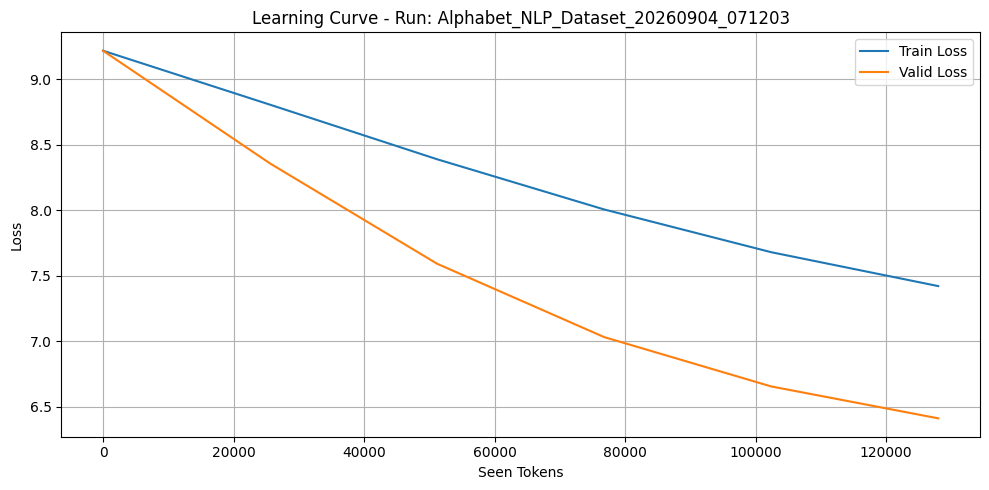



[Sample 1]
 .
 در به و و از.
 که.
 و و را از���،��� را و این���ی به��شود������ را و. می�� در در���های این، از��ها که از��ی�� و��ی.
 از می،���

[Sample 2]
 ��� که و���.
، به می��������های،، از در به�� و و از..��ها�� در را به��.،��ی و�� و��های، این به��.، در،.��� و���. می

[Sample 3]
 ��،.
. در و���ی به�����های این�����های، را می�����ی در به��ی��ها در��ی��ی در به��ی، در را.

��� و می��های را. از��


Training:  44%|███████▉          | 153600/346944 [00:53<00:26, 7204.80t/s, B/S=27.32, Loss=7.2166, LR=2.04e-04]


Valid Loss: 6.2570

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


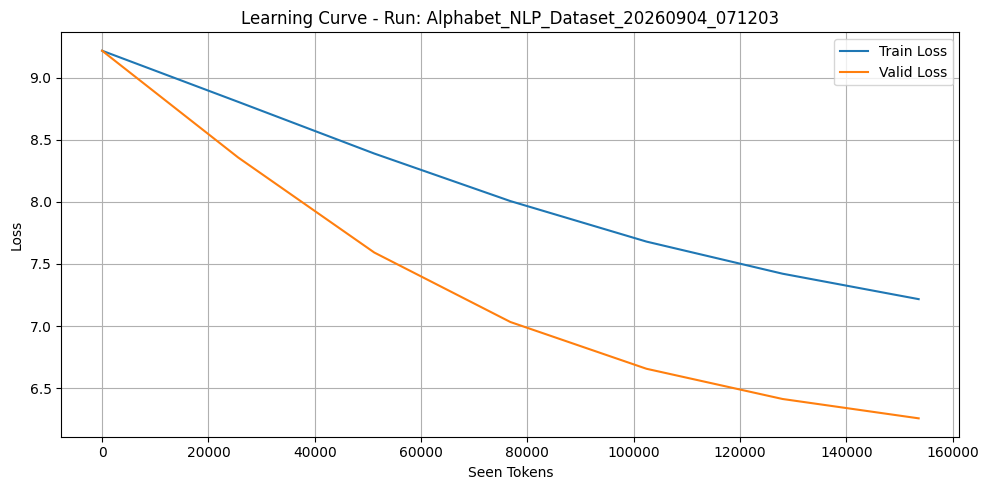



[Sample 1]
 �� به است.����یَ این�����ی در��ی این به در به از از��ی و��ها را ازَی را می���ها���ها.

-َ، به��ی را این��ی در���،،، را

[Sample 2]
 �����ی این���ها��ی��شود به��کند می��ی می می به��های��ی در آن��یَ، از��ی به�����ی��ی آن به��های این��ای در و��� و از

[Sample 3]
 .
 از���.


 و از این و این��� که به��های و آن��ها و و،��ی در می��ی��ی��ی می��یََ،.


. و از آن��یَ از��


Training:  52%|█████████▎        | 179200/346944 [01:03<00:22, 7409.00t/s, B/S=38.30, Loss=7.0569, LR=1.71e-04]


Valid Loss: 6.1499

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


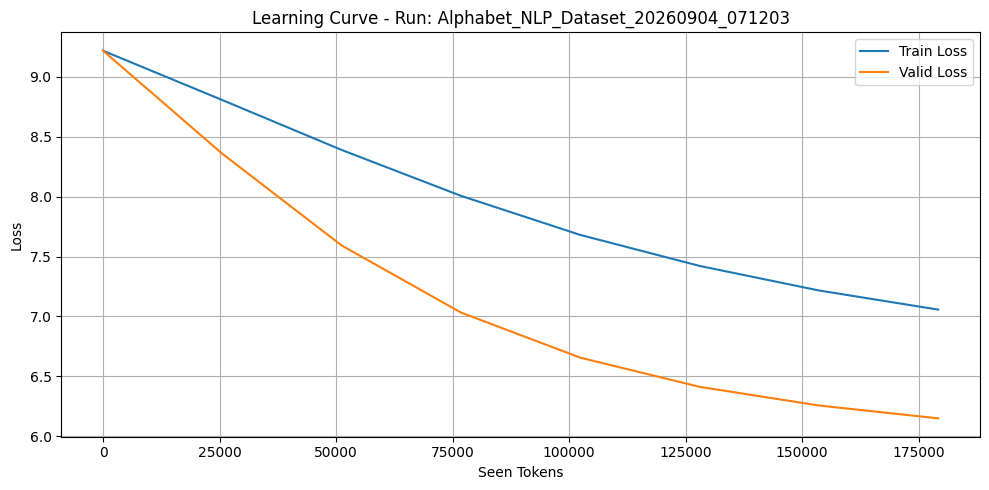



[Sample 1]
 �� به را به و و می��ی در می��.���ی، و،، این�����ی به��های با از را می�� و این���، را��های به��ای،، به��های به��ی���، از و با

[Sample 2]
 ��ها،، به، و��ی و می از این، از، و، به است که در،،�����ی،.
-���های می��ها���های به��ی��ی را از به��های می���های می می��� و در

[Sample 3]
 و از در به می��ی،، از به����ی و با می��ی این��ی به��ی،،��ی در می��ی در��ی در از این است.

-��های این و آن را در به���


Training:  59%|██████████▌       | 203776/346944 [01:12<00:24, 5916.90t/s, B/S=42.48, Loss=6.9215, LR=1.38e-04]


Valid Loss: 6.0740

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


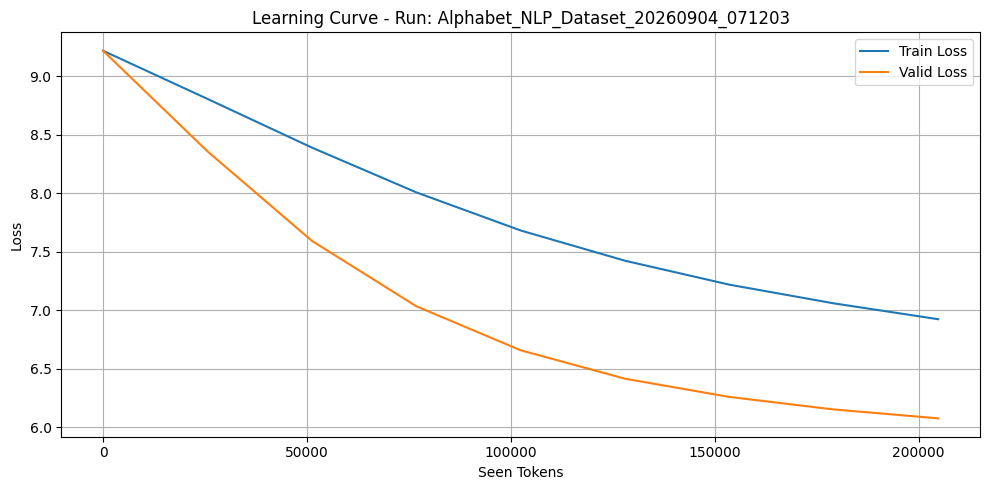



[Sample 1]
 ��اند..
```







```
��شود��ی و��های می��که��ی می��ای به.،��های به��ای.��ی،، به��ی���،��ی

[Sample 2]
 �� را��ها، می��ی��های می��کند
-

 که از می��های این و����های به��کند.

-







��یَ و می���، این و از از از

[Sample 3]
 و در، به می��ی در این این به����ی و و�����ی در این��های و به��ی این���یَ، به��ی��ی می���ی آن��ی به��های این وَ.





Training:  66%|███████████▉      | 229376/346944 [01:21<00:19, 5948.50t/s, B/S=39.59, Loss=6.8081, LR=1.06e-04]


Valid Loss: 6.0102

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


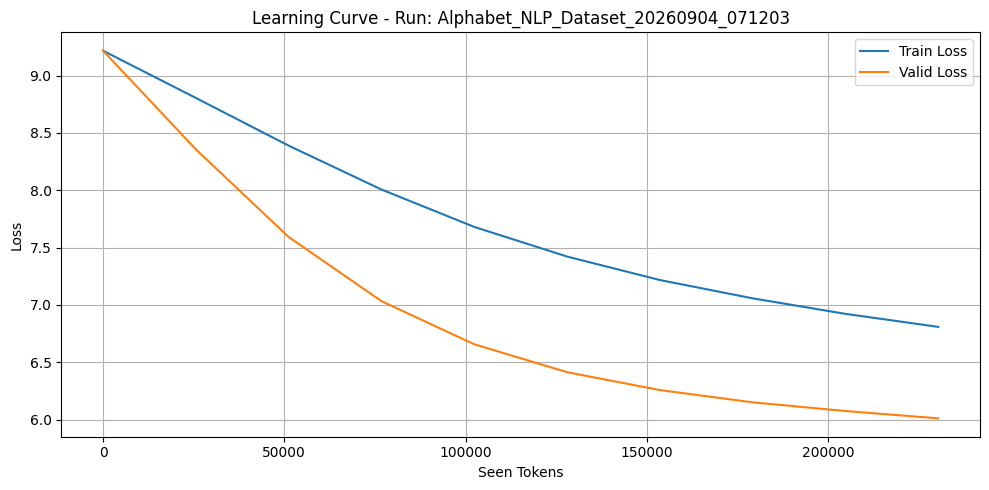



[Sample 1]
 ��اند.��کند از به��های از این��ی و به���ها که به این می��ی این می��ی از می��ای از در، در در به��ی می��ی به��ی به��ی آن��ی

[Sample 2]
 �� را در��ی در به��ی آن��� و و��ای و به��ها���ی این�����ی در با آن��های می��ها که در��ها، به��های در به��های می��های��������

[Sample 3]
 و از آن��ی این��ها��ها و با به��های��های آن��ی آن��ی می��ی آن��ی��ی آن��ی می���یَ به��های از از با این این��ی به���


Training:  74%|█████████████▎    | 256000/346944 [01:30<00:11, 8037.48t/s, B/S=41.75, Loss=6.7126, LR=7.74e-05]


Valid Loss: 5.9776

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


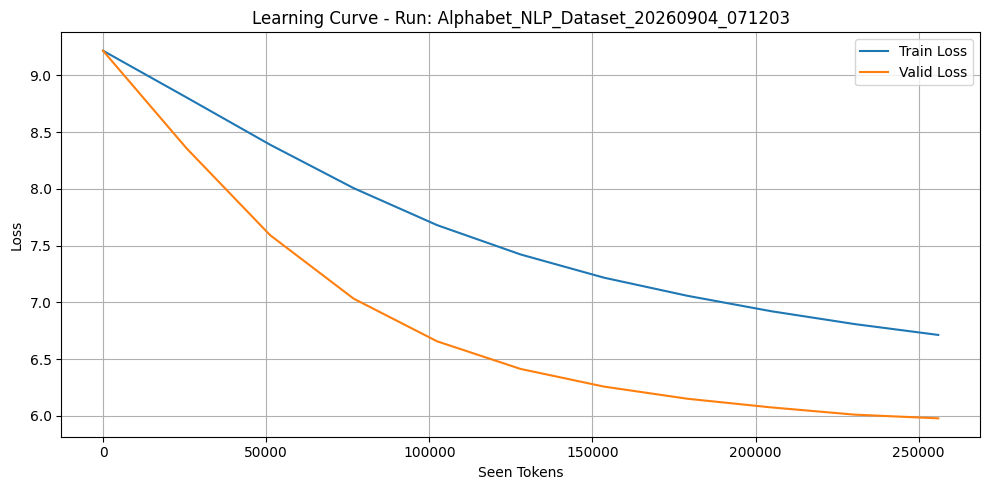



[Sample 1]
 �� به���ی به��ی به��های از این در می��ی می و آن�����ی به��هایَِ،��ها که این��دهد که��ی و، می��ی��های به��ی���، و از را

[Sample 2]
 .**

**
 **- **



�����کند به��یَِ به��های��ی در با به��های می��ها را از��ها، به��های در به��های می��های از به می���

[Sample 3]
 ��اند..


- ****- به��هایََِ���یَْ و در��های این��ی این��یِْ��ی در به��یَی،، به�����های می��یِ به��


Training:  81%|██████████████▌   | 280576/346944 [01:39<00:11, 5770.51t/s, B/S=39.89, Loss=6.6292, LR=5.43e-05]


Valid Loss: 5.9496

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


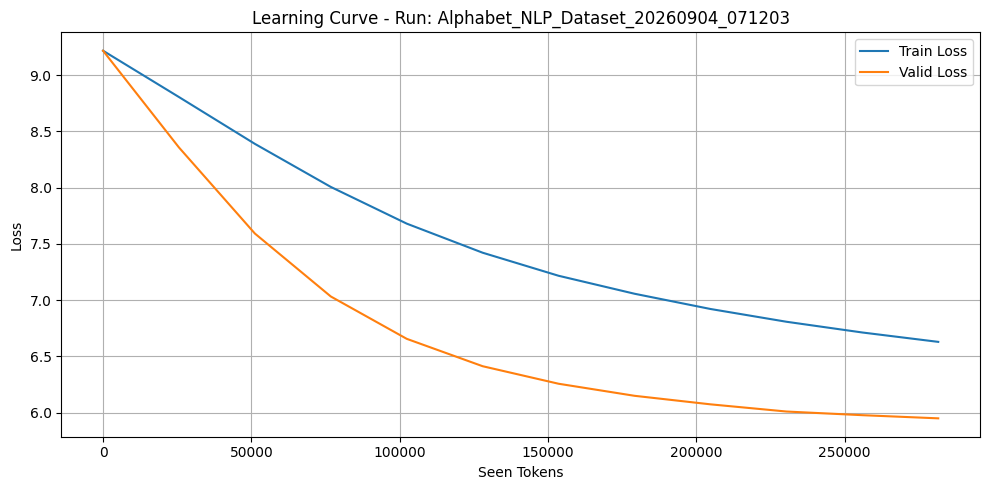



[Sample 1]
 �� به را به و در آن در به��های در��کند. و به در��یَ��های و در به��یَِْ این���یِه���ی�����ی و به��یْم��ی از این آن می��

[Sample 2]
 ��ها، از��های��ی به��ی از آن از این��اند که و آن، با به��های و با این��ای از به��های این به��ی آن��شود، می��های در و آن و این می���

[Sample 3]
 و از و به این از��های از از این آن��های و در به�����ی از��های به��یَِ���ی این��ی��ی��ی در به��ی این�����های و در این��ی این���


Training:  88%|███████████████▉  | 306176/346944 [01:48<00:07, 5742.05t/s, B/S=40.65, Loss=6.5525, LR=3.77e-05]


Valid Loss: 5.9292

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


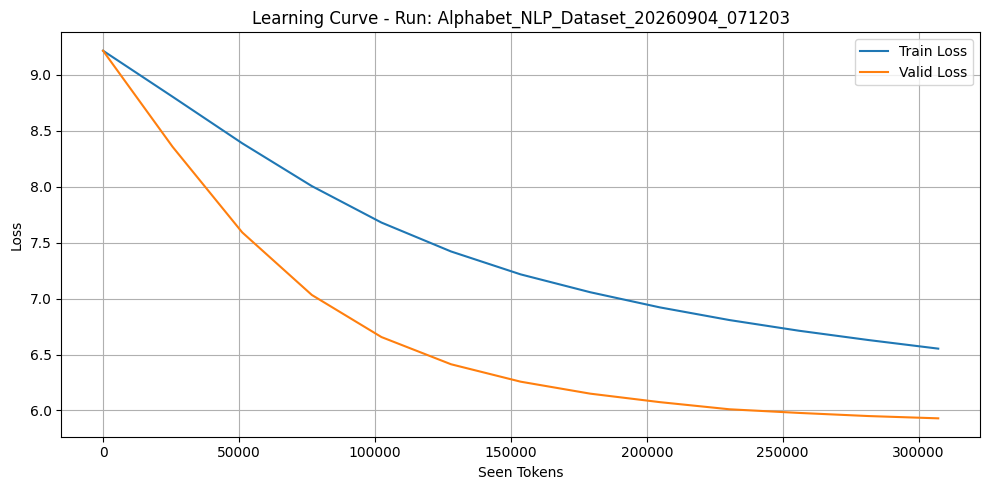



[Sample 1]
 �� به را به می��ی این در و می��ی آن��ی می و آن�����ی این��های با��یَ��ای،��ها.

.
```
**








 ****



[Sample 2]
 ��ها، از��های از از��های می��کند
-

 و این از و این�����ی و با��ی می��ی��های به��ی��کند از می��های��کند به��های در از

[Sample 3]
 و از و به و و در به از از��ها و با��یِ���ی آن��ها،، در��ی و این��یَ و به��ی به��ی به��ی به�����های یک به��اند.




Training:  96%|█████████████████▏| 331776/346944 [01:57<00:02, 7460.27t/s, B/S=40.33, Loss=6.4882, LR=2.88e-05]


Valid Loss: 5.9202

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


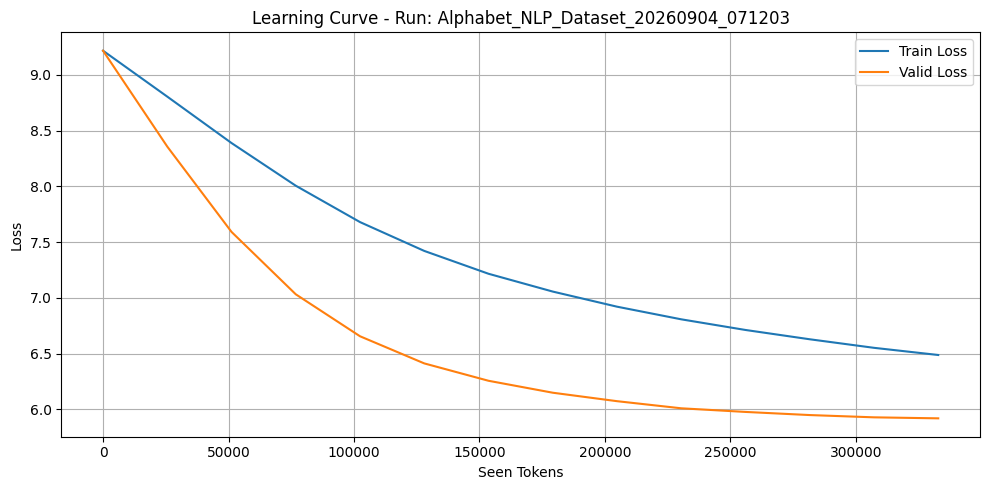



[Sample 1]
 ��دهد.��کند:






```
```
���ها.
��ی این��های یک به��ی این است

 **در این آن�����ی در به��ی یک و به��ی���، و این���

[Sample 2]
 �� آن می��ی آن، از از به��های و و و��ی به را از می��های این می��.
-






-
**





��ی در می��های می��������

[Sample 3]
 و از و به و��ی از��های آن��های با این������ی از و و از از و در��ی و در از و به��ی��ی به��ی این��ی به�����های با این این��ی��


Training: 100%|█████████████████▉| 346112/346944 [02:06<00:00, 2795.62t/s, B/S=36.40, Loss=6.4575, LR=2.73e-05]


Valid Loss: 5.9120

✅ Best Model Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/best_model.pt!
✅ Best Model's Config Saved to /data/logs/Alphabet_NLP_Dataset_20260904_071203/config.yaml!


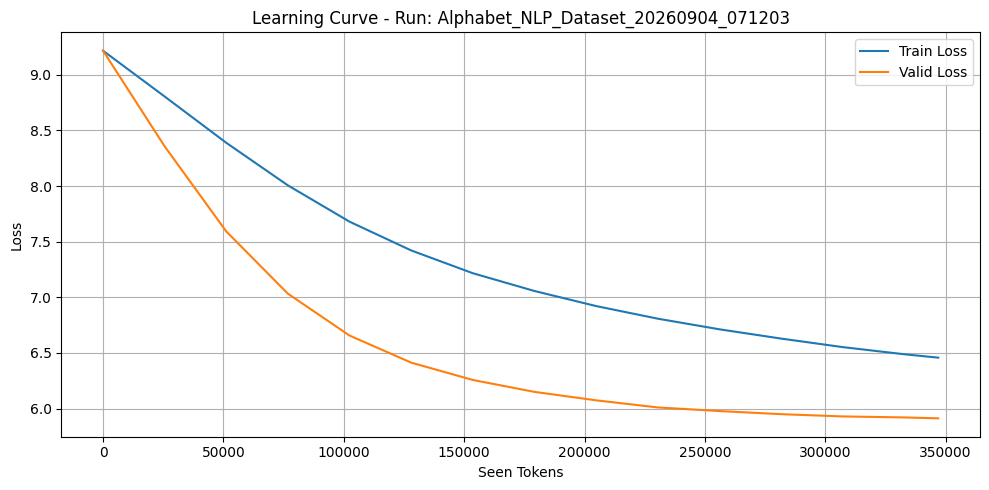



[Sample 1]
 �� به��های��ی این است.



```
�����ها.
```

-

- در این��ی به��یَه و��ی آن��ی به��ی در��یََم، این���

[Sample 2]
 ��ها، از��های��ی به��ی آن��های و به�����ی به�����ی از���های این��ای در��ی به��ها، به��های در به��های می��های�����شود

[Sample 3]
 و از و به می��یَ������های آن��های می�����یَْ و در از و این��یِِْ، به��ی��یَ���ی���ها از���ی��هایَ���های��ی از در��


Training: 100%|██████████████████| 346944/346944 [02:15<00:00, 2795.62t/s, B/S=36.40, Loss=6.4575, LR=2.73e-05]

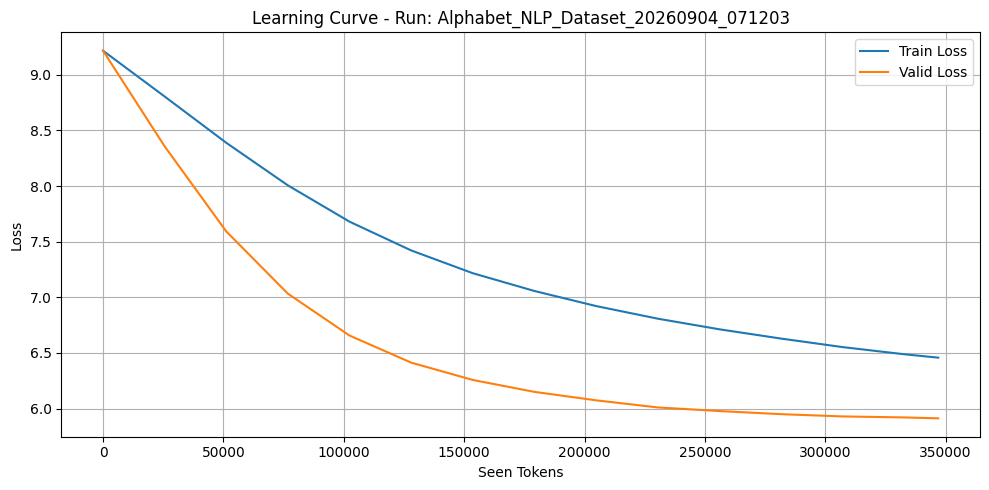

Training: 100%|██████████████████| 346944/346944 [02:16<00:00, 2547.23t/s, B/S=36.40, Loss=6.4575, LR=2.73e-05]


In [24]:
if train_loader is None or valid_loader is None:
    print("⚠️ Trainer cannot be created because one of the loaders is None.")
else:
    trainer = LLMTrainer(model, optimizer, train_loader, valid_loader, tokenizer, config=cfg)
    trainer.train()

# 🟢 **Generate**

In [25]:
prompts = [
    'هوش مصنوعی چیست؟',
    ]

In [26]:
for prompt in prompts:
    # Generate n_rep samples
    gen_continuations = generate(model, tokenizer, prompt, n_rep=3, max_seq_len=32, T=0.9, top_k=10)

    # Display using the chat style function
    print(100*"=")
    display_chat_style(prompt, gen_continuations, tokenizer)
    print(100*".")


[Sample 1]
 



-
 ** این��ی و در این��ی آن��ها.
```

-���

[Sample 2]
 



**
 **- **



�����کند���های و به��شود به��های

[Sample 3]
 در از و به به��ی از این به��های، در با این است و با از و و از از و در
....................................................................................................
